# GISLR — 1st-place solution recreation (1D-CNN + Transformer)

**Pipeline stage:** stage 1 (training), parallel to `gislr.1.models.training.ipynb`.
This is a *port*, not a new experiment: it reproduces the Kaggle GISLR 1st-place
solution (hoyso48, public LB ~0.89) end to end — feature pipeline, augmentation,
architecture and training regime — on this repo's canonical split and registry.
Implements **TODO §4.2**.

The reference notebook was recovered from git history
(`git show fd1c7aa:src/gislr.0.competition.entry.1st.ipynb`, removed in `f7be9a1`)
and read in full rather than re-derived from memory, as §4.2 requires.

## Why a separate notebook from `gislr.1.models.training.ipynb`

TODO §4.2 says to add this as a *section* of the shared training notebook. That
was written on the assumption that only the **architecture** differs. Having now
read the reference, it does not: the architecture is one of five changes, and
three of them are incompatible with the shared notebook's data path.

| | `gislr.1.models.training.ipynb` | here |
|---|---|---|
| landmarks | ME_126 / ME_132 / FP_118 | **FP_118** (`POINT_LANDMARKS` verbatim) |
| coordinates | xy, un-normalized | xy, **reference-point normalized** |
| features | 2 ch/landmark (position) | **6 ch/landmark** (position + lag-1 + lag-2) |
| NaN | zeroed at cache-build time | **preserved** (normalization + masking need it) |
| sequence | uniform subsample to 128 | native rate, random crop to 384 |
| augmentation | none | resample · mirror · affine · temporal & spatial mask |
| model | GRU / LSTM / BiLSTM / CausalConv1D | Conv1DBlock ×3 + Transformer, ×2 stages |
| regime | `v2-plateau-300` (ReduceLROnPlateau + early stop) | `fp-onecycle-300` (cosine, no early stop, AWP) |

The shared notebook exists to enforce *all-else-identical* across architectures.
Injecting a run that changes the features, the sequence handling, the
augmentation and the optimizer would destroy exactly the property it protects.
So: **separate notebook, separate config — same canonical split, same registry,
same `meta.json` schema**, so the leaderboard still compares like with like.

## What is shared, and therefore still comparable

- `modules/model/data.py::get_canonical_split` — stratified 90/10, seed 42, 9,448 val.
- `modules/model/registry.py` — one epoch-seconds run folder, `meta.json` schema v3.
- `modules/scripts/eval_gru.py` — canonical per-class eval (extended in this
  change to score 1st-place-preprocessed runs correctly).

## Artifacts

| path | content |
|---|---|
| `data/cache/gislr/features/{train,val}_fp118-xy_nan_{data,offsets}.npy` | NaN-preserving feature cache (~3 GB train) |
| `data/models/<run_id>/meta.json` | run record (schema v3) |
| `data/models/<run_id>/{best,last}.pt` | checkpoints (gitignored); `last.pt` every epoch = auto-resume |
| `data/models/<run_id>/assets/history.json` | per-epoch curves |
| `data/models/<run_id>/assets/landmarks.npy` | the subset's holistic row indices |

## Resumability

`last.pt` is written atomically every epoch with model / optimizer / Lookahead /
scheduler / AWP-step state. An interrupted run resumes in place via its pointer
file; a **finished** run never is (fresh run folder per training start). §5 is
the only long cell, and it is the resumable one — killing the kernel costs at
most one epoch.

## Every cell is independently re-runnable

§1 is the only shared prerequisite (imports, paths, constants). Every other
section re-reads the config from disk and loads its inputs from the cache, so
tweaking a hyperparameter and re-running one cell is enough.

## 0. Read this before running — what this can and cannot deliver

**Three things to be clear-eyed about.**

### 0.1 This model is OFFLINE-ONLY. It is not a deployment candidate.

`CLAUDE.md`: *"Streaming viability drives everything."* This architecture is not
streaming-viable, for reasons that are properties of the reference design, not
of the port:

- the readout is a **global average over the whole sequence**;
- **self-attention is unmasked in time** — frame *t* attends to frame *t+k*;
- the **normalization statistics are whole-sequence** (mean of the reference
  landmark over every frame, std over every frame and landmark);
- the lag differences are **forward** (`dx[t] = x[t+1] - x[t]`).

It is registered with `streaming: false` and belongs beside `BiLSTM`: an
accuracy reference that prices the causality gap. The last two points are
cheaply fixable (`diff_mode: "backward"` is a config knob; the normalization
needs a running estimator, TODO §7.2). The first two need a causal attention
mask and a last-frame readout — a real but bounded follow-up, and the most
valuable thing to do *after* this reproduces.

**The transferable win is the feature pipeline, not the model.** Normalization
and lag features are architecture-independent and are exactly what TODO §7.2/§7.3
plan to add to the streaming models. If this port lands near 0.89 while the GRU
sits at 0.756, that gap is the size of the prize available to §7 — measured
rather than assumed.

### 0.2 A single run on our split should not be expected to hit 0.89

The reported ~0.89 is the **Kaggle leaderboard** score of a **4-seed ensemble**
trained on **all 94,477 videos** (`train_folds(CFG, ['all'])` at seeds 42–45).
This notebook trains **one seed** on our **90/10 canonical split**, holding out
9,448 videos it therefore never sees.

A realistic expectation for a single model here is **~0.84–0.88**, and the
comparison that matters is against the 0.7565 GRU on the *same* split. Reaching
0.89 requires the ensemble (§7), which is 4× the compute and cannot be scored on
the canonical split at all (those models train on the val set).

### 0.3 Cost — measured, ~1.4 h for the full 300 epochs

The reference reports 6–7 h/fold on a TPU v3-8. The committed config was chosen by
measurement on this machine (RTX 4080 Super 16 GB, i7-14700K, 28 logical cores):

| config | ms/step | 300 epochs | peak GPU |
|---|---|---|---|
| batch 512, `num_workers` 0 | 640 | 8.9 h | 7.9 GB |
| **batch 512, `num_workers` 8** | **101** | **1.4 h** | **7.9 GB** |
| batch 512, `num_workers` 16 | 106 | 1.5 h | 7.9 GB |
| batch 256, `num_workers` 12 | 228 | 6.3 h | 4.0 GB |
| batch 1024, `num_workers` 12 | 1858 | 12.9 h | 15.7 GB |
| batch 512, w 8, `awp_delta: 0` | 66 | 0.9 h | 7.9 GB |

Two things drove that, both worth knowing before changing anything:

**1. Length bucketing.** GISLR clip lengths are severely skewed — median **22**
frames, mean 38, p99 **219**, max 537. Padding each batch to its own maximum
saves almost nothing when batches are composed randomly, because the max of a few
hundred draws sits deep in the tail: the first timing run measured a median padded
length of **277** against a median clip of **22**, about 6.4x wasted compute
(worse in wall time, attention being O(T²)).
`features.LengthBucketedBatchSampler` groups similar-length clips, measured
**7.12x → 1.13x** padding overhead. It keeps batch composition random across
epochs — shuffle, sort only within a pool, shuffle the batches — because a
straight sort by length would make the LR schedule and the BatchNorm statistics
see a systematic length ramp.

**2. The dataloader was ~85% of the step.** Once padding was fixed, augmentation
on a single CPU thread dominated: 640 ms/step at `num_workers: 0` versus 101 ms
at 8. Gains flatten past 8 (16 and 20 measure slightly *worse*), so 8 is the
knee — not the maximum the CPU could run.

Dead ends, so you don't repeat them: **`torch.compile` raises `TritonMissing`** —
there is no Triton wheel on Windows, which closes the main GPU-side lever.
**`pin_memory` must stay off** — a padded batch at 512 is ~557 MB, so pinning it
across workers exhausts page-locked host memory (`CUDA error: out of memory` from
the pin thread). **bf16 is not faster** than fp16 here (105 vs 104 ms), though it
is the right fallback if AWP produces NaNs, since it cannot overflow.

**Still run §4b before §5** — it re-measures on the day and warns if padding
overhead exceeds 2x. If the estimate is unacceptable, the levers in
`src/config/gislr.firstplace.json` are, in order: `awp_delta: 0` (0.9 h, costs
accuracy), `epochs`, then `hidden_size`.

### 0.4 Known instability — and what run 1787483814 actually did

The reference author reports **NaN loss roughly one run in five** at
`awp_delta: 0.2`. The first full run here failed differently, and worse:

| epoch | train loss | train acc | val acc |
|---|---|---|---|
| 14 | 2.009 | 0.715 | **0.746** |
| 15 | 5.788 | 0.027 | 0.017 |
| 16 | 5.526 | 0.007 | 0.025 |
| 299 | 4.543 | 0.148 | 0.179 |

Epoch 15 is the exact epoch **AWP and LateDropout both switch on**. The loss did
not go NaN — it pinned at ln(250) = 5.52, i.e. a uniform predictor — and never
recovered. Weights from `best.pt` (epoch 15) vs `last.pt` (epoch 300) say what
happened: the stem's weight norm went **16 -> 224** while `stem_bn.running_var`
went **4.8 -> 8467**, and every downstream BatchNorm scale collapsed toward zero
to suppress the exploded signal. That is a gradient blow-up at the AWP
transition, not a plateau — 285 of 300 epochs trained a dead model.

Three changes, all in `src/config/gislr.firstplace.json` and
`modules/model/{optim,train_fp}.py`:

1. **`grad_clip: 1.0`** (was `0.0`, matching the reference). AWP steps from a
   gradient measured at an adversarially perturbed point, which is exactly where
   an unclipped update is most dangerous.
2. **BatchNorm running statistics are frozen during AWP's adversarial forward**
   (`optim.frozen_bn_stats`). That pass exists only to produce a gradient; it was
   also writing perturbed activations into the statistics used at eval time.
3. **Stopping conditions** — `collapse_ratio`/`collapse_patience` (fast guard)
   and `es_patience`/`es_min_delta` (ordinary plateau), §5. Replayed against the
   history above, the collapse guard ends the run at **epoch 18** instead of 300.

**It still diverges.** Re-run `1787492560`, with all three changes in place,
died at the same epoch — val acc 0.7415 at epoch 15, 0.039 at 16 — and the
collapse guard ended it at epoch 18 after **9.1 min** instead of 2 h. Clipping
softened the blow-up (epoch-16 loss 5.08 vs 5.79) without preventing it, and
from that epoch average the model takes roughly **20 steps** to die: a
systematic runaway, not one bad update.

So the guard works and the cause is still open. Epoch 15 switches on **two**
things, and neither has been tested alone — that is what **§5b** does, in ~30
minutes, and it should be run before another full §5.


## 1. Setup

Imports, tunables, resolved paths. The **only** cell other sections depend on.
No hyperparameters live here — they are in
[`src/config/gislr.firstplace.json`](config/gislr.firstplace.json), read at run
time by `modules.model.train_fp.load_fp_config` (same principle as
`gislr.1.models.training.ipynb` §2).

In [1]:
# =====
# Setup: imports, shared constants, resolved paths
# =====
import json
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from modules.dataset.landmark.subsets import get_subset
from modules.model import data as D
from modules.model import features as F
from modules.model import registry as R
from modules.model.architectures import ARCHS, build_model
from modules.model.train_fp import DEFAULT_CONFIG, load_fp_config, train_firstplace
from modules.paths import CACHE_DIR, MODELS_DIR, gislr_dir

CONFIG_PATH = DEFAULT_CONFIG          # src/config/gislr.firstplace.json
SMOKE_BATCH = 8                       # batch size for the §3 CPU smoke test
TIMING_BATCHES = 30                   # batches to time in §4 before extrapolating

DATA_DIR = gislr_dir()                # GISLR only — never resolve_datasets()
SIGN2IDX = D.load_label_map(DATA_DIR)

print(f"torch {torch.__version__} · CUDA {torch.cuda.is_available()}"
      + (f" · {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else ""))
print(f"gislr data   : {DATA_DIR}")
print(f"feature cache: {F.FEATURES_DIR}")
print(f"registry     : {MODELS_DIR}")
print(f"config       : {CONFIG_PATH}")
print(f"classes      : {len(SIGN2IDX)}")

torch 2.13.0+cu130 · CUDA True · NVIDIA GeForce RTX 4080 SUPER
gislr data   : C:\Users\user2\.cache\kagglehub\competitions\asl-signs
feature cache: C:\Users\user2\sign2speech\src\data\cache\gislr\features
registry     : C:\Users\user2\sign2speech\src\data\models
config       : C:\Users\user2\sign2speech\src\config\gislr.firstplace.json
classes      : 250


## 2. Config — the resolved recipe, and how it maps to the reference

Everything the run will use, printed before anything trains. The right-hand
column is the reference's own value so any deviation is visible rather than
buried.

In [2]:
# =====
# Load + display the training config, mapped against the reference values
# =====
CFG = load_fp_config(CONFIG_PATH)
HYP = CFG["hyp"]

REFERENCE = {  # hoyso48's CFG / get_model defaults, for side-by-side comparison
    "batch_size": "512 (64 x 8 TPU replicas)",
    "lr": "4e-3 (5e-4 x 8 replicas)",
    "hidden_size": 192,
    "num_layers": "2 stages (dim 192); 4 for the '4x' model",
    "dropout": 0.2,
    "kernel_size": 17,
    "num_heads": 4,
    "expand": 2,
    "late_dropout": 0.8,
    "late_dropout_start_epoch": 15,
    "weight_decay": "0.1 (decoupled, lr-scaled)",
    "epochs": "300 (400 in the final solution)",
    "warmup_epochs": 0,
    "lr_min_ratio": "lr_min 1e-6",
    "grad_clip": "None (clipvalue=1 commented out)",
    "label_smoothing": 0.1,
    "awp_delta": 0.2,
    "awp_start_epoch": 15,
    "lookahead_k": 5,
    "lookahead_alpha": 0.5,
    # deliberate deviations — the reference runs a fixed-length cosine with no
    # stopping conditions at all (see §0.4 for why ours has them)
    "es_patience": "none (fixed 300-400 epochs)",
    "es_min_delta": "none",
    "collapse_ratio": "none",
    "collapse_patience": "none",
}

rows = [{"key": k, "this run": v, "reference": REFERENCE.get(k, "—")}
        for k, v in HYP.items()]
print(f"architecture : {CFG['architecture']}  (streaming={ARCHS[CFG['architecture']].streaming})")
print(f"regime       : {CFG['regime']}")
print(f"subsets      : {CFG['subsets']} · coords {CFG['coords']}")
print(f"features     : {CFG['features']}")
print()
display(pd.DataFrame(rows).set_index("key"))

if HYP["batch_size"] != 512:
    print(f"\nNOTE: batch {HYP['batch_size']} vs the reference's 512, with lr scaled to "
          f"{HYP['lr']:g}. Keep the lr/batch ratio if you change either.")
if CFG["features"]["diff_mode"] != "forward":
    print("\nNOTE: diff_mode is CAUSAL — this is no longer the reference configuration.")

architecture : conv1d_transformer  (streaming=False)
regime       : fp-onecycle-300
subsets      : ['FP_118'] · coords xy
features     : {'max_len': 384, 'diff_mode': 'forward', 'augment': True}



,this run,reference
key,,
batch_size,512.000,512 (64 x 8 TPU replicas)
lr,0.004,4e-3 (5e-4 x 8 replicas)
hidden_size,192.000,192
num_layers,2.000,2 stages (dim 192); 4 for the '4x' model
dropout,0.200,0.2
kernel_size,17.000,17
num_heads,4.000,4
expand,2.000,2
late_dropout,0.800,0.8


## 3. Verification before training (TODO §4.2 — "which parts are streaming-safe")

Three checks that are cheap on CPU and expensive to discover 40 epochs in:

1. **Feature pipeline** — shapes, channel layout, NaN handling, and that the
   normalization actually removes signer scale.
2. **Mirror closure** — `flip_lr` swaps every left/right landmark pair and the
   subset is closed under it (an unclosed subset would silently corrupt the
   augmentation).
3. **Causality audit** — which parts of the model read the future. This is the
   evidence behind the `streaming: false` registration in §0.1, measured rather
   than asserted.

In [3]:
# =====
# 3a. Feature pipeline on one real video: shapes, channels, normalization
# =====
CFG = load_fp_config(CONFIG_PATH)
subset = get_subset(CFG["subsets"][0])
train_split, val_split = D.get_canonical_split(DATA_DIR, SIGN2IDX)

raw = F.load_video_raw(DATA_DIR / train_split["path"].iloc[0], subset.array, "xy")
kept = F.drop_empty_frames(raw)
ref_idx = int(np.searchsorted(subset.array, F.REF_LANDMARK))
feats = F.preprocess(kept, ref_idx, CFG["features"]["max_len"],
                     CFG["features"]["diff_mode"])

P = len(subset)
print(f"subset {subset.name}: {P} landmarks · ref landmark {F.REF_LANDMARK} at index {ref_idx}")
print(f"raw      {raw.shape}  NaN {np.isnan(raw).mean():.1%}")
print(f"filtered {kept.shape}  (all-NaN frames dropped)")
print(f"features {feats.shape}  expected (T, {F.CHANNELS_PER_LANDMARK * P}) "
      f"= position {2*P} | lag-1 {2*P} | lag-2 {2*P}")
assert feats.shape[1] == F.CHANNELS_PER_LANDMARK * P
assert np.isfinite(feats).all(), "NaN/inf leaked into the model input"

pos, d1, d2 = feats[:, :2*P], feats[:, 2*P:4*P], feats[:, 4*P:]
print(f"\nchannel stats  position std {pos.std():.3f} · lag-1 std {d1.std():.3f} "
      f"· lag-2 std {d2.std():.3f}")

# the point of the normalization: a scaled/shifted signer must produce the SAME
# features (this is what removes signer size and distance to camera)
scaled = F.preprocess(kept * 0.7 + 0.15, ref_idx, CFG["features"]["max_len"],
                      CFG["features"]["diff_mode"])
delta = np.nanmax(np.abs(scaled - feats))
print(f"scale/shift invariance: max |Δfeature| = {delta:.2e}  "
      f"({'OK' if delta < 1e-3 else 'FAILED — normalization is not doing its job'})")

subset FP_118: 118 landmarks · ref landmark 17 at index 6
raw      (112, 118, 2)  NaN 21.9%
filtered (112, 118, 2)  (all-NaN frames dropped)
features (112, 708)  expected (T, 708) = position 236 | lag-1 236 | lag-2 236

channel stats  position std 0.844 · lag-1 std 0.085 · lag-2 std 0.101
scale/shift invariance: max |Δfeature| = 2.38e-06  (OK)


In [4]:
# =====
# 3b. Mirror map: subset closed under left/right swap, flip is an involution
# =====
subset = get_subset(load_fp_config(CONFIG_PATH)["subsets"][0])
perm = F.mirror_permutation(subset.array)   # asserts closure internally

n_swapped = int((perm != np.arange(len(perm))).sum())
print(f"{subset.name}: {n_swapped}/{len(perm)} landmarks swap, "
      f"{len(perm) - n_swapped} are midline")
assert np.array_equal(perm[perm], np.arange(len(perm))), "mirror is not an involution"

x = np.random.default_rng(0).random((5, len(subset), 2)).astype(np.float32)
assert np.allclose(F.flip_lr(F.flip_lr(x, perm), perm), x), "flip_lr is not self-inverse"
print("flip_lr: involution OK · x -> 1-x OK · every pair present in the subset")

for name, group in [("left hand", range(468, 489)), ("lips", [61, 291]),
                    ("eyes", [33, 263])]:
    pairs = [(a, F.MIRROR_PAIRS.get(a)) for a in list(group)[:3]]
    print(f"  {name:10s} {pairs}")

FP_118: 112/118 landmarks swap, 6 are midline
flip_lr: involution OK · x -> 1-x OK · every pair present in the subset
  left hand  [(468, 522), (469, 523), (470, 524)]
  lips       [(61, 291), (291, 61)]
  eyes       [(33, 263), (263, 33)]


In [5]:
# =====
# 3c. Causality audit — does the model read the future? (evidence for §0.1)
# =====
CFG = load_fp_config(CONFIG_PATH)
subset = get_subset(CFG["subsets"][0])
feature_dim = len(subset) * F.CHANNELS_PER_LANDMARK
hyp = {**CFG["hyp"], "late_dropout_start_step": 0}

model = build_model(CFG["architecture"], feature_dim, len(SIGN2IDX), hyp).eval()
print(f"{ARCHS[CFG['architecture']].model_name}: "
      f"{sum(p.numel() for p in model.parameters())/1e6:.2f}M params, "
      f"feature_dim {feature_dim}")

torch.manual_seed(0)
T = 64
x = torch.randn(2, T, feature_dim)
lengths = torch.tensor([T, T])
with torch.no_grad():
    base = model(x, lengths)
    corrupted = x.clone()
    corrupted[:, T // 2:] = torch.randn_like(corrupted[:, T // 2:])  # rewrite the future
    after = model(corrupted, lengths)
drift = (base - after).abs().max().item()
print(f"\ncorrupting frames {T//2}..{T} changes the logits by {drift:.3e}")
print("=> reads the future (expected: global pooling + unmasked attention). "
      "OFFLINE-ONLY." if drift > 1e-5 else "=> causal.")

# ...but the convolutional half IS causal; verify the depthwise conv in isolation
from modules.model.architectures import CausalDWConv1D
dw = CausalDWConv1D(8, kernel_size=17).eval()
y = torch.randn(1, 40, 8)
with torch.no_grad():
    a = dw(y)[:, :20]
    y2 = y.clone(); y2[:, 20:] = torch.randn_like(y2[:, 20:])
    b = dw(y2)[:, :20]
print(f"CausalDWConv1D: future corruption changes the past by "
      f"{(a-b).abs().max().item():.3e} => causal, so a streaming variant only "
      f"needs a masked attention + last-frame readout")

# masking sanity: padded frames must not change a shorter sequence's logits
with torch.no_grad():
    short = model(x[:, :30], torch.tensor([30, 30]))
    padded = torch.cat([x[:, :30], torch.randn(2, 20, feature_dim)], 1)
    same = model(padded, torch.tensor([30, 30]))
print(f"padding invariance: max |Δlogit| = {(short-same).abs().max().item():.3e} "
      f"(must be ~0, else the mask is leaking)")

Conv1DTransformer: 1.83M params, feature_dim 708



corrupting frames 32..64 changes the logits by 8.278e-02
=> reads the future (expected: global pooling + unmasked attention). OFFLINE-ONLY.
CausalDWConv1D: future corruption changes the past by 0.000e+00 => causal, so a streaming variant only needs a masked attention + last-frame readout
padding invariance: max |Δlogit| = 6.333e-08 (must be ~0, else the mask is leaking)


## 4. Feature cache + one-epoch timing

The cache is built **once** per (split, subset) and reused by every later run —
skip-if-exists, atomic writes. Roughly **3 GB** for the FP_118 train split.

The timing cell is the one to look at before committing to §5: it runs a handful
of real training steps (AWP included) and extrapolates to the full 300 epochs.
It creates **no** registry run.

In [6]:
# =====
# 4a. Build the NaN-preserving feature caches (skip-if-exists, ~3 GB train)
# =====
from tqdm.auto import tqdm

CFG = load_fp_config(CONFIG_PATH)
subset = get_subset(CFG["subsets"][0])
train_split, val_split = D.get_canonical_split(DATA_DIR, SIGN2IDX)
print(f"canonical split: {len(train_split)} train / {len(val_split)} val")

for split_df, prefix in ((train_split, "train"), (val_split, "val")):
    bar = tqdm(total=len(split_df), desc=f"cache {prefix}/{subset.name}", dynamic_ncols=True)
    paths = F.build_nan_cache(split_df, prefix, subset, CFG["coords"], DATA_DIR,
                              progress=lambda done, total: bar.update(done - bar.n))
    bar.update(bar.total - bar.n); bar.close()
    print(f"  {prefix}: {[p.name for p in paths]}")

canonical split: 85029 train / 9448 val


cache train/FP_118:   0%|          | 0/85029 [00:00<?, ?it/s]

  train: ['train_fp118-xy_nan_data.npy', 'train_fp118-xy_nan_offsets.npy']


cache val/FP_118:   0%|          | 0/9448 [00:00<?, ?it/s]

  val: ['val_fp118-xy_nan_data.npy', 'val_fp118-xy_nan_offsets.npy']


In [7]:
# =====
# 4b. Time a few real training steps and extrapolate to the full run
# =====
from torch.utils.data import DataLoader
from modules.model.optim import AWP, Lookahead, cosine_one_cycle

CFG, HYP = load_fp_config(CONFIG_PATH), load_fp_config(CONFIG_PATH)["hyp"]
subset = get_subset(CFG["subsets"][0])
train_split, _ = D.get_canonical_split(DATA_DIR, SIGN2IDX)
tr_data, tr_off = F.build_nan_cache(train_split, "train", subset, CFG["coords"], DATA_DIR)

ds = F.FirstPlaceDataset(train_split, tr_data, tr_off, subset,
                         augment_data=CFG["features"]["augment"],
                         max_len=CFG["features"]["max_len"],
                         diff_mode=CFG["features"]["diff_mode"],
                         mmap=HYP["num_workers"] > 0)
sampler = F.LengthBucketedBatchSampler(F.cached_lengths(tr_off), HYP["batch_size"],
                                       shuffle=True, drop_last=True)
# pin_memory stays False: a padded batch at 512 is ~557 MB and pinning it across
# workers exhausts page-locked host memory (CUDA OOM from the pin thread).
loader = DataLoader(ds, batch_sampler=sampler, collate_fn=F.collate_fn,
                    num_workers=HYP["num_workers"],
                    persistent_workers=HYP["num_workers"] > 0,
                    prefetch_factor=2 if HYP["num_workers"] > 0 else None,
                    pin_memory=False)
steps_per_epoch = len(loader)

device = torch.device("cuda")
feature_dim = len(subset) * F.CHANNELS_PER_LANDMARK
model = build_model(CFG["architecture"], feature_dim, len(SIGN2IDX),
                    {**HYP, "late_dropout_start_step": 0}).to(device)
opt = torch.optim.RAdam(model.parameters(), lr=HYP["lr"],
                        weight_decay=HYP["weight_decay"], decoupled_weight_decay=True)
lookahead = Lookahead(opt, k=HYP["lookahead_k"], alpha=HYP["lookahead_alpha"])
awp = AWP(model, delta=HYP["awp_delta"], start_step=0)   # worst case: AWP on from step 0
crit = torch.nn.CrossEntropyLoss(label_smoothing=HYP["label_smoothing"])
scaler = torch.amp.GradScaler("cuda")

seq_lens, t0 = [], None
model.train()
for i, (feats, lengths, labels) in enumerate(loader):
    if i == TIMING_BATCHES:
        break
    if i == 5:                      # skip warmup/cudnn autotune batches
        torch.cuda.synchronize(); t0 = time.perf_counter()
    seq_lens.append(int(lengths.max()))
    feats, labels = feats.to(device), labels.to(device)
    opt.zero_grad(set_to_none=True)
    with torch.amp.autocast("cuda"):
        loss = crit(model(feats, lengths), labels)
    scaler.scale(loss).backward()
    if awp.active(0) and awp.perturb():
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda"):
            adv = crit(model(feats, lengths), labels)
        scaler.scale(adv).backward()
        awp.restore()
    scaler.unscale_(opt)
    scaler.step(opt); scaler.update(); lookahead.sync()
torch.cuda.synchronize()

per_step = (time.perf_counter() - t0) / (TIMING_BATCHES - 5)
epoch_min = per_step * steps_per_epoch / 60
raw_len = F.cached_lengths(tr_off)
overhead = np.mean(seq_lens) / np.clip(raw_len, None, CFG["features"]["max_len"]).mean()
print(f"batch {HYP['batch_size']} · {steps_per_epoch} steps/epoch · "
      f"padded length: median {int(np.median(seq_lens))}, max {max(seq_lens)} "
      f"(cap {CFG['features']['max_len']})")
print(f"clip lengths: median {int(np.median(raw_len))}, mean {raw_len.mean():.0f}, "
      f"p99 {int(np.percentile(raw_len, 99))}  ->  padding overhead {overhead:.2f}x")
if overhead > 2:
    print("  WARNING: padded length far above the typical clip — length bucketing "
          "is not taking effect; check LengthBucketedBatchSampler is in use.")
print(f"{per_step*1000:.0f} ms/step (AWP on)  ->  ~{epoch_min:.2f} min/epoch")
print(f"\nESTIMATE for {HYP['epochs']} epochs: {epoch_min*HYP['epochs']/60:.1f} h "
      f"(+ validation)")
print(f"  with awp_delta=0 it would be roughly {epoch_min*HYP['epochs']/60/2:.1f} h")
print(f"  peak GPU memory: {torch.cuda.max_memory_allocated()/1e9:.1f} GB of "
      f"{torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB")
del model, opt, lookahead, scaler; torch.cuda.empty_cache()

batch 512 · 166 steps/epoch · padded length: median 39, max 331 (cap 384)
clip lengths: median 22, mean 38, p99 219  ->  padding overhead 1.88x
241 ms/step (AWP on)  ->  ~0.67 min/epoch

ESTIMATE for 300 epochs: 3.3 h (+ validation)
  with awp_delta=0 it would be roughly 1.7 h
  peak GPU memory: 6.7 GB of 17 GB


## 5. Train (TODO §4.2)

One registry run per configured subset. **This is the long cell** — check §4b's
estimate first.

Everything is config-driven (`src/config/gislr.firstplace.json`); nothing here is
tunable in the cell, deliberately. Interrupting is safe: `last.pt` is written
every epoch and re-running this cell resumes the same run folder.

**The run can now stop before the epoch cap** (the reference's never does — §0.4
is why ours can):

| stop | trigger | recorded as |
|---|---|---|
| collapse | val acc below `collapse_ratio` (0.5) of this run's own best, for `collapse_patience` (3) consecutive epochs | `stop_reason: "collapse"` |
| nan | train or val loss non-finite | `stop_reason: "nan"` |
| plateau | no val-acc gain > `es_min_delta` (0.001) for `es_patience` (30) epochs | `stop_reason: "plateau"` |

`es_patience` is deliberately generous: a one-cycle cosine makes real gains late,
while the LR anneals, so a short patience would cut the run's best phase. The
collapse guard is the one that matters for the §0.4 failure — it fires in 3
epochs, not 30. Either way `meta.json` carries `training.stop_reason`
(`completed`/`plateau`/`collapse`/`nan`), so a short run is never ambiguous.


In [8]:
# =====
# 5. Train the 1st-place port (resumable; one run folder per subset)
# =====
RUN_DIRS = train_firstplace()
for name, run_dir in RUN_DIRS.items():
    meta = R.load_meta(run_dir)
    print(f"{name}: run {run_dir.name} · best val {meta['metrics']['train_val_acc']:.4f} "
          f"· {meta['training']['epochs_trained']} epochs "
          f"· {meta['training']['wall_time_min']:.0f} min")

conv1d_transformer · regime fp-onecycle-300 · coords xy · subsets ['FP_118']
  features: max_len=384 diff_mode=forward augment=True
  AWP delta=0.2 from epoch 15 · Lookahead k=5 · label smoothing 0.1 · grad_clip 1.0
  stops: plateau after 30 epochs without a +0.001 val-acc gain · collapse after 3 epochs below 50% of best


gislr/conv1d_transformer/fp118-xy · run 1787492560:   0%|          | 0/300 [00:00<?, ?it/s]

fp118-xy: 1.83M params · feature_dim 708 · 166 steps/epoch
fp118-xy: STOPPED at epoch 18 (collapse) — val acc below 50% of best (0.7415) for 3 epochs — the run diverged, see history.json
fp118-xy: DONE best_val_acc=0.7415 run_dir=C:\Users\user2\sign2speech\src\data\models\1787492560
FP_118: run 1787492560 · best val 0.7415 · 18 epochs · 9 min


## 5b. Which switch kills the run? (diagnostic, ~30 min)

**Run this before spending another 2 h on §5.** Two runs have now died at the same
place — `1787483814` (300 epochs, no guard) and `1787492560` (stopped at 18 by the
collapse guard, 9.1 min). Epoch 15 turns on **two** things at once, and grad
clipping + the BatchNorm fix were not enough:

| run | grad_clip | frozen BN stats | val acc ep15 | ep16 | outcome |
|---|---|---|---|---|---|
| 1787483814 | 0.0 | no | 0.746 | 0.017 | ran all 300 epochs, ended at 0.179 |
| 1787492560 | 1.0 | yes | 0.7415 | 0.039 | collapse stop at epoch 18 |

Softer, still fatal. From run 1787492560's epoch-16 *average* loss (5.076 against
ln(250)=5.52) the model takes roughly **20 steps** to die — a systematic runaway,
not a single bad update, which is why clipping alone did not fix it.

So separate the two switches. Three arms, same seed, same data, same LR schedule:

| arm | `awp_delta` | `late_dropout` | asks |
|---|---|---|---|
| A | **0** | 0.8 | does LateDropout alone kill it? |
| B | 0.2 | **0** | does AWP alone kill it? |
| C | 0.2 | 0.8 | control — reproduces the failure |

Each runs to epoch 25 via `stop_after_epoch`, which **does not touch the cosine
schedule** (still laid out over 300 epochs, so epoch 15 sits at the same LR it
does in a real run — lowering `epochs` to 25 instead would put it at 15% of peak
and answer a different question). Arms that collapse exit at ~18 on the guard.

Whichever arm survives past epoch 16 is the innocent one. Expected reading:

- **A survives, B dies** → AWP is the problem: `awp_delta: 0.1`, and if that
  still dies, `awp_start_epoch` later or `awp_delta: 0` (costs ~0.9 h/run, and
  the reference credits AWP with a real chunk of its accuracy).
- **B survives, A dies** → LateDropout 0.8 is too aggressive at this batch
  size/LR: lower `late_dropout` to ~0.4, or move `late_dropout_start_epoch` later.
- **Both die alone** → the model is simply not stable at `lr: 4e-3` by epoch 15
  and the shared fix is a lower LR (or bf16, which cannot overflow).
- **Both survive alone, C dies** → it is the interaction; stagger the two start
  epochs.

These are real registry runs (they get folders and `meta.json`), tagged
`notes_suffix` = `ABLATION …` so they are identifiable. They stay `eval_status:
pending`, so they never enter the canonical leaderboard.


In [ ]:
# =====
# 5b. Switch ablation: LateDropout vs AWP (tunables: ARMS, ABLATE_TO_EPOCH)
# =====
from copy import deepcopy

ABLATE_TO_EPOCH = 25          # hard stop; the cosine still spans hyp["epochs"]
ARMS = {                      # name -> hyp overrides
    "A_no_awp":          {"awp_delta": 0.0},
    "B_no_late_dropout": {"late_dropout": 0.0},
    "C_control":         {},
}

BASE = load_fp_config(CONFIG_PATH)
results = {}
for arm, overrides in ARMS.items():
    cfg = deepcopy(BASE)
    cfg["hyp"].update(overrides, stop_after_epoch=ABLATE_TO_EPOCH)
    cfg["notes_suffix"] = (f"ABLATION {arm} ({overrides or 'no change'}) — §5b, "
                           f"NOT a leaderboard run")
    print(f"\n=== arm {arm}: {overrides or 'control'} ===")
    run_dir = train_firstplace(cfg)[cfg["subsets"][0]]
    tr = R.load_meta(run_dir)["training"]
    hist = json.loads((run_dir / "assets" / "history.json").read_text())
    results[arm] = {"run": run_dir.name, "stop": tr["stop_reason"],
                    "epochs": tr["epochs_trained"], "best_epoch": tr["best_epoch"],
                    "val@15": round(hist["val_acc"][14], 4) if len(hist["val_acc"]) > 14 else None,
                    "val@16": round(hist["val_acc"][15], 4) if len(hist["val_acc"]) > 15 else None,
                    "val@last": round(hist["val_acc"][-1], 4)}

display(pd.DataFrame(results).T)
survived = [a for a, r in results.items() if r["stop"] != "collapse"]
print(f"\nsurvived the epoch-15 switch: {survived or 'NONE — see §5b for that case'}")


## 6. Results — learning curves and the comparison that matters

The 1st-place port against this repo's existing leaderboard, on the **same
canonical split and metric**. `train_val_acc` is the training-loop number; the
canonical figure arrives in §7.

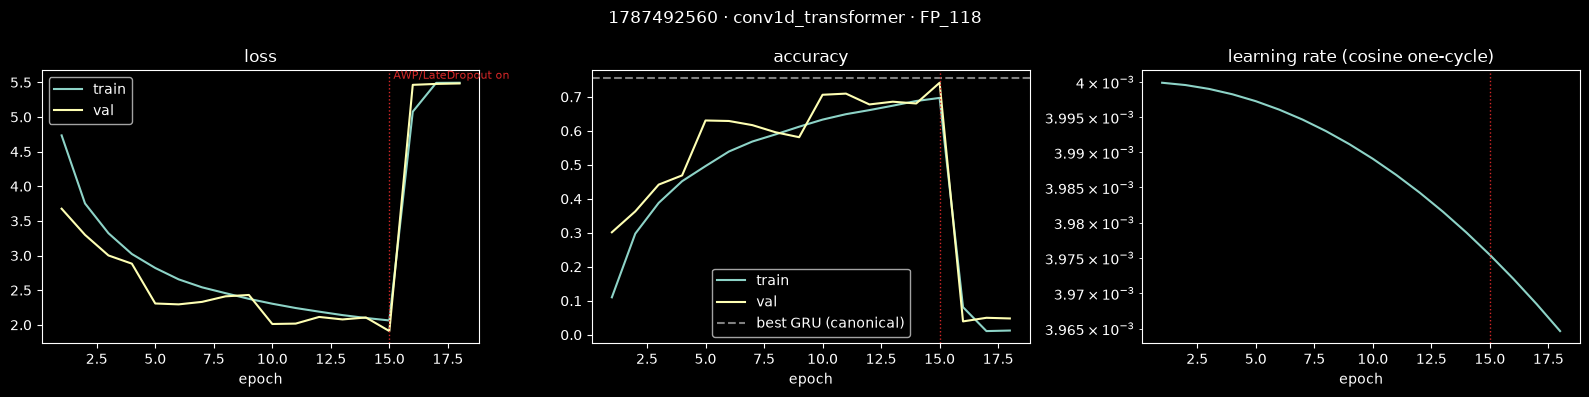

best epoch 15: val 0.7415 · train 0.6969 · train/val gap -0.045
Compare that gap with the 0.155-0.24 of the un-augmented runs (docs/logs/daily/2026-07-19.md): augmentation + AWP should shrink it.
stop: collapse after 18/300 epochs (best epoch 15)


In [9]:
# =====
# 6a. Learning curves for this run (train/val loss + accuracy, LR)
# =====
CFG = load_fp_config(CONFIG_PATH)
subset_name = CFG["subsets"][0]
run_dir = R.pointer_run_dir(f"{CFG['dataset']}_{CFG['architecture']}_"
                            f"{D.subset_tag(subset_name, CFG['coords'])}")
HYP_ = CFG["hyp"]
history = json.loads((run_dir / "assets" / "history.json").read_text())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs = range(1, len(history["train_loss"]) + 1)
axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="val")
axes[0].set_title("loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="val")
axes[1].axhline(0.7565, ls="--", c="grey", label="best GRU (canonical)")
axes[1].set_title("accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
axes[2].plot(epochs, history["lr"]); axes[2].set_yscale("log")
axes[2].set_title("learning rate (cosine one-cycle)"); axes[2].set_xlabel("epoch")
# AWP and LateDropout both switch on here — the epoch run 1787483814 died at, so
# it belongs on every curve rather than being reconstructed from the config later
switch = min(HYP_["awp_start_epoch"], HYP_["late_dropout_start_epoch"])
for ax in axes:
    ax.axvline(switch, color="tab:red", ls=":", lw=1)
axes[0].text(switch, axes[0].get_ylim()[1], " AWP/LateDropout on",
             color="tab:red", fontsize=8, va="top")
fig.suptitle(f"{run_dir.name} · {CFG['architecture']} · {subset_name}")
fig.tight_layout(); plt.show()

best_i = int(np.argmax(history["val_acc"]))
gap = history["train_acc"][best_i] - history["val_acc"][best_i]
print(f"best epoch {best_i+1}: val {history['val_acc'][best_i]:.4f} · "
      f"train {history['train_acc'][best_i]:.4f} · train/val gap {gap:.3f}")
print("Compare that gap with the 0.155-0.24 of the un-augmented runs "
      "(docs/logs/daily/2026-07-19.md): augmentation + AWP should shrink it.")

tr = R.load_meta(run_dir)["training"]
print(f"stop: {tr.get('stop_reason')} after {tr['epochs_trained']}/{tr['epoch_cap']} "
      f"epochs (best epoch {tr['best_epoch']})")
if best_i + 1 <= switch < len(history["val_acc"]):
    print("WARNING: the best epoch is at or before the AWP/LateDropout switch — "
          "the run got worse the moment the late regularizers came on. That is "
          "the S0.4 failure, not a plateau: check grad_clip is on, then drop "
          "awp_delta to 0.1.")

In [10]:
# =====
# 6b. Leaderboard — 1st-place port vs every existing registry run
# =====
import duckdb

lb = duckdb.sql(f"""
    SELECT architecture, subset, coords, streaming,
           round(coalesce(metrics.overall_accuracy, metrics.train_val_acc), 4) AS acc,
           metrics.eval_status AS eval,
           training.regime AS regime, n_params, run_id
    FROM read_json_auto('{R.META_GLOB.replace(chr(92), '/')}')
    WHERE dataset = 'gislr'
    ORDER BY acc DESC
    LIMIT 15
""").df()
display(lb)
print("`acc` is the canonical overall_accuracy where available, else the "
      "training-loop val accuracy — see the `eval` column.")

,architecture,subset,coords,streaming,acc,eval,regime,n_params,run_id
0,bilstm,ME_126,xy,False,0.7569,canonical,v2-plateau-300,2751218,1784447175
1,gru,ME_126,xy,True,0.7565,canonical,v2-plateau-300,851698,1784453891
2,gru,ME_126,xy,True,0.7565,canonical,v2-plateau-300,851698,1784447187
3,bilstm,FP_118,xy,False,0.7525,canonical,v2-plateau-300,2718418,1784397301
4,gru,FP_118,xy,True,0.7505,canonical,v2-plateau-300,839378,1784455294
5,gru,FP_118,xy,True,0.7505,canonical,v2-plateau-300,839378,1784451456
6,bilstm,ME_126,xy,False,0.7504,canonical,v2-plateau-300,2751218,1784395799
7,gru,ME_132,xy,True,0.7493,canonical,v2-plateau-300,860938,1784449770
8,gru,ME_132,xy,True,0.7493,canonical,v2-plateau-300,860938,1784454580
9,bilstm,ME_132,xy,False,0.7476,canonical,v2-plateau-300,2775818,1784396516


`acc` is the canonical overall_accuracy where available, else the training-loop val accuracy — see the `eval` column.


## 7. Canonical evaluation handoff

The training-loop number is not leaderboard-eligible. `eval_gru.py` re-scores the
run from raw parquet on the canonical val set and promotes `meta.json` to
`eval_status: "canonical"`.

It dispatches on the checkpoint's `features` key, so a run trained here is scored
through the 1st-place preprocessing rather than the default one — feeding it the
default 2-channel un-normalized features would report near-chance accuracy.

Then rebuild the index and run `gislr.2.models.evaluation.ipynb` for the full
leaderboard, confusion matrices and the TFLite export.

In [11]:
# =====
# 7. Print the canonical-eval commands for every run produced above
# =====
CFG = load_fp_config(CONFIG_PATH)
for name in CFG["subsets"]:
    rd = R.pointer_run_dir(f"{CFG['dataset']}_{CFG['architecture']}_"
                           f"{D.subset_tag(name, CFG['coords'])}")
    if rd is not None:
        print(R.eval_command(rd))
print("\n.venv/Scripts/python.exe src/modules/scripts/build_model_index.py")
print("\nThen: src/gislr.2.models.evaluation.ipynb (leaderboard, confusion "
      "matrices, TFLite export).")
print("\nNOTE: TFLite export via modules/model/keras_export.py has NOT been "
      "extended to this architecture (it rebuilds GRU/LSTM/BiLSTM/CausalConv1D "
      "in native Keras). Exporting the port needs Keras equivalents of "
      "Conv1DBlock/ECA/TransformerBlock — out of scope here, filed in TODO §4.2.")

.venv/Scripts/python.exe src/modules/scripts/eval_gru.py src/data/models/1787492560

.venv/Scripts/python.exe src/modules/scripts/build_model_index.py

Then: src/gislr.2.models.evaluation.ipynb (leaderboard, confusion matrices, TFLite export).

NOTE: TFLite export via modules/model/keras_export.py has NOT been extended to this architecture (it rebuilds GRU/LSTM/BiLSTM/CausalConv1D in native Keras). Exporting the port needs Keras equivalents of Conv1DBlock/ECA/TransformerBlock — out of scope here, filed in TODO §4.2.


## 7b. Where the accuracy actually goes — per class, and what it is confused with

Runs after §7's canonical eval (it needs the `assets/val_predictions.npz` that
writes). Nothing here re-runs inference: the confusion matrix is built from those
cached predictions, so this cell is cheap and independently re-runnable.

Row *i* of the matrix is true class *i*, normalized to sum to 1 — the diagonal is
that sign's recall, the off-diagonal is where its errors go. The pair table is the
actionable half: a pair with a high rate in **both** directions is a genuinely
ambiguous sign pair in this landmark representation (TODO §7.1), while a
one-directional pair is usually a weak class leaking into a strong neighbour.

Writes `assets/confusion.png` and `assets/confused_pairs.csv` into the run folder.


In [12]:
# =====
# 7b. Per-class accuracy + confusion matrix for this run (tunables: N_SHOW, N_PAIRS)
# =====
from modules.model.report import confusion_matrix, plot_confusion

N_SHOW, N_PAIRS = 15, 25          # classes per table, confused pairs to list

CFG = load_fp_config(CONFIG_PATH)
subset_name = CFG["subsets"][0]
run_dir = R.pointer_run_dir(f"{CFG['dataset']}_{CFG['architecture']}_"
                            f"{D.subset_tag(subset_name, CFG['coords'])}")
meta = R.load_meta(run_dir)
assert meta["metrics"]["eval_status"] == "canonical", (
    f"run {run_dir.name} is not canonically evaluated yet — run §7's command first")

SIGNS = {v: k for k, v in SIGN2IDX.items()}
per_class = pd.read_csv(run_dir / "assets" / "per_class_accuracy.csv")
cm = confusion_matrix(run_dir, n_classes=meta["n_classes"])

print(f"run {run_dir.name} · overall {meta['metrics']['overall_accuracy']:.4f} "
      f"· macro {meta['metrics']['macro_accuracy']:.4f} "
      f"· median {meta['metrics']['median_class_accuracy']:.4f} "
      f"· {meta['metrics']['n_classes_below_50pct']} classes below 50%")
print(f"best {N_SHOW} classes:")
display(per_class.tail(N_SHOW).iloc[::-1].reset_index(drop=True))
print(f"worst {N_SHOW} classes:")
display(per_class.head(N_SHOW).reset_index(drop=True))

off = cm.copy()
np.fill_diagonal(off, 0.0)
pairs = pd.DataFrame([
    {"true": SIGNS[i], "predicted": SIGNS[j],
     "rate": round(float(off[i, j]), 3),
     "true_recall": round(float(cm[i, i]), 3),
     "reverse_rate": round(float(off[j, i]), 3)}
    for i, j in (np.unravel_index(k, off.shape)
                 for k in np.argsort(off, axis=None)[::-1][:N_PAIRS])])
pairs.to_csv(run_dir / "assets" / "confused_pairs.csv", index=False)
print(f"top {N_PAIRS} confused pairs (high `reverse_rate` too = mutual confusion):")
display(pairs)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = plot_confusion(cm, f"{meta['architecture']} · {meta['subset']}/{meta['coords']} "
                        f"· run {run_dir.name} · overall "
                        f"{meta['metrics']['overall_accuracy']:.4f}", ax)
fig.colorbar(im, ax=ax, fraction=0.046, label="fraction of true class (log)")
fig.tight_layout()
fig.savefig(run_dir / "assets" / "confusion.png", dpi=110)
plt.show()
R.register_assets(run_dir, confusion_png="assets/confusion.png",
                  confused_pairs="assets/confused_pairs.csv")
print(f"wrote {run_dir / 'assets'}/confusion.png + confused_pairs.csv")


AssertionError: run 1787492560 is not canonically evaluated yet — run §7's command first

## 8. Next steps

**State after two runs (2026-08-23):** `1787483814` (300 epochs, 2.0 h) and
`1787492560` (18 epochs, 9.1 min, stopped by the collapse guard) both died at
epoch 15, the step AWP and LateDropout switch on. Canonical **0.7459** from the
first one's surviving epoch-15 checkpoint — below the 0.7565 GRU, and not a
measurement of the recipe. The guards work; the divergence itself is unsolved.

Ordered by what each buys:

1. **Run §5b (~30 min).** Three short arms separate LateDropout from AWP. Nothing
   else about this recipe can be believed until one of them survives epoch 15,
   and a second full §5 run before that is 2 h spent on a coin flip.
2. **Apply §5b's verdict and re-run §5**, then canonical-eval (§7) and read §7b.
3. **Ablate the feature pipeline on the GRU** — normalization alone, then
   normalization + lag features, all else identical, via
   `gislr.1.models.training.ipynb` (TODO §7.2/§7.3). Independent of 1-2, and the
   point: the features are the part of this recipe a *streaming* model can have.
   The architecture is not deployable; the features are.
4. **Causal variant of this architecture** — masked attention + last-frame
   readout + `diff_mode: "backward"` + a running-statistics normalizer. Turns an
   offline reference into a deployment candidate and prices the causality gap.
5. **The 4-seed ensemble on all data** (§0.2) only if a Kaggle leaderboard number
   is the actual goal — it cannot be scored on the canonical split, and the
   competition closed in 2023, so this buys a comparison figure at best.
